In [33]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [5]:
df = pd.read_csv("loan_prediction_dataset.csv")

df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


## Basic EDA

In [7]:
print(f"Shape: {df.shape}")
print(f"Info: {df.info()}")
print(f"Null Values: {df.isnull().sum()}")
print(f"Desciption: {df.describe()}")

Shape: (2000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
Info: None
Null Values: Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64
Desciption:                Age         Income  Credit_Score   Loan_Amount   Loan_Term  \
count  2000.000000    2000.000000   2000.000000   2000.000000  2000.00000   
mean     43.805500   84533.585000    5

## Encoding the Objects

In [17]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output = False)

encoded = ohe.fit_transform(df[['Employment_Status']])

In [18]:
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(['Employment_Status']))

print(encoded_df)

      Employment_Status_Employed  Employment_Status_Self-Employed  \
0                            1.0                              0.0   
1                            0.0                              1.0   
2                            0.0                              1.0   
3                            0.0                              0.0   
4                            0.0                              0.0   
...                          ...                              ...   
1995                         1.0                              0.0   
1996                         1.0                              0.0   
1997                         0.0                              1.0   
1998                         1.0                              0.0   
1999                         0.0                              0.0   

      Employment_Status_Unemployed  
0                              0.0  
1                              0.0  
2                              0.0  
3                      

In [19]:
df = pd.concat([df.drop(columns = "Employment_Status", axis = 1), encoded_df], axis = 1)

df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed
0,56,81788,334,15022,48,0,1.0,0.0,0.0
1,69,102879,781,21013,24,1,0.0,1.0,0.0
2,46,58827,779,39687,60,0,0.0,1.0,0.0
3,32,127188,364,16886,24,0,0.0,0.0,1.0
4,60,25655,307,26256,36,0,0.0,0.0,1.0


## Target Distribution

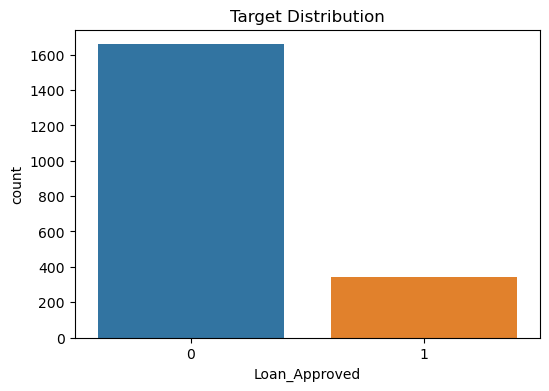

In [22]:
plt.figure(figsize = (6, 4))

sns.countplot(x = "Loan_Approved", data = df)

plt.title("Target Distribution")

plt.show()

## Feature Distribution

In [23]:
features = ["Income", "Credit_Score", "Loan_Amount", "Loan_Term"]

for feature in features:
    print(f"Skewness of {feature} : {df[feature].skew()}")

Skewness of Income : 0.042257072051863166
Skewness of Credit_Score : -0.017200873337721384
Skewness of Loan_Amount : -0.006767903608228579
Skewness of Loan_Term : 0.06530134404728842


## Correlation Checker

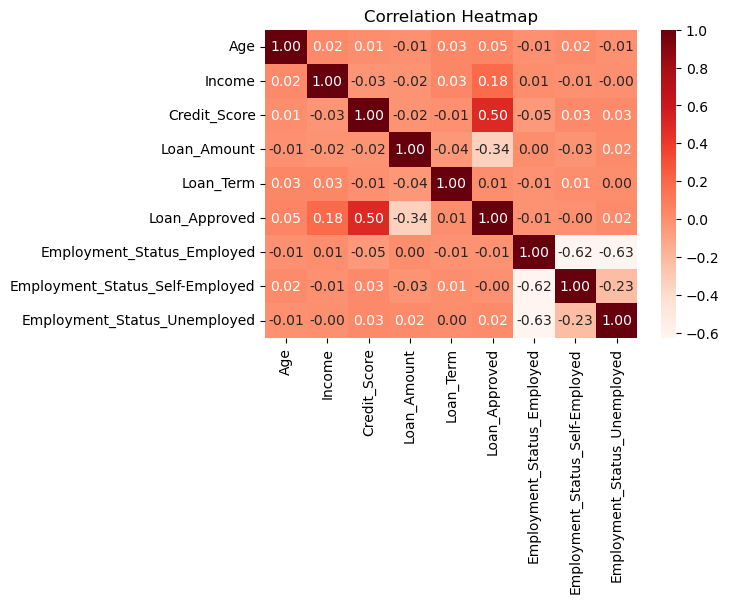

In [25]:
corr_mat = df.corr(numeric_only = True)

plt.figure(figsize = (6, 4))

sns.heatmap(corr_mat, annot = True, fmt = ".2f", cmap = "Reds")
plt.title("Correlation Heatmap")
plt.show()

## Train Test Split

In [38]:
X = df.drop(columns = "Loan_Approved", axis = 1)
Y = df["Loan_Approved"]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

## Preprocessing Pipelines

In [36]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('power', PowerTransformer(method = 'yeo-johnson')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore')),
])
numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

In [37]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

## Preprocess Data

In [40]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

## Class Imbalance Check

In [41]:
class_ratio = y_train.value_counts(normalize = True)
print(class_ratio)

0    0.82875
1    0.17125
Name: Loan_Approved, dtype: float64


## Model Training

In [48]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

In [49]:
model.fit(x_train_processed, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [53]:
y_pred = model.predict(x_test_processed)

y_prob = model.predict_proba(x_test_processed)[:, 1]

In [55]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)

print("MODEL PERFORMANCE")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc:.4f}")

MODEL PERFORMANCE
Accuracy: 0.8825
Precision: 0.5963
Recall: 0.9559
F1 Score: 0.7345
ROC AUC: 0.9117


In [56]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.87      0.92       332
           1       0.60      0.96      0.73        68

    accuracy                           0.88       400
   macro avg       0.79      0.91      0.83       400
weighted avg       0.92      0.88      0.89       400



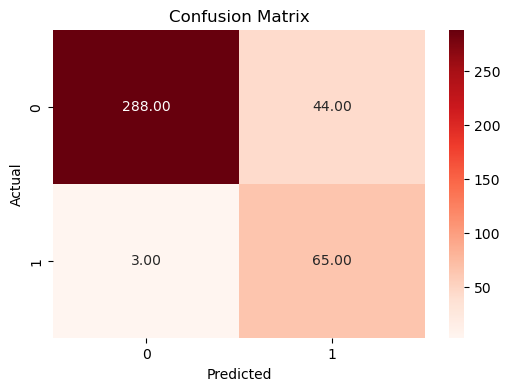

In [58]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 4))

sns.heatmap(cm, annot = True, fmt = ".2f", cmap = "Reds")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

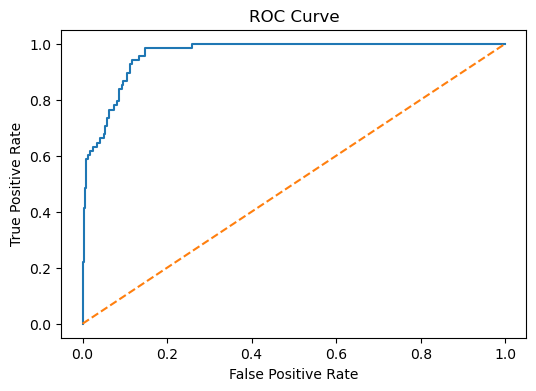

In [59]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize = (6, 4))

plt.plot(fpr, tpr, label = f"AUC = {roc}")

plt.plot([0, 1], [0, 1], linestyle = "--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

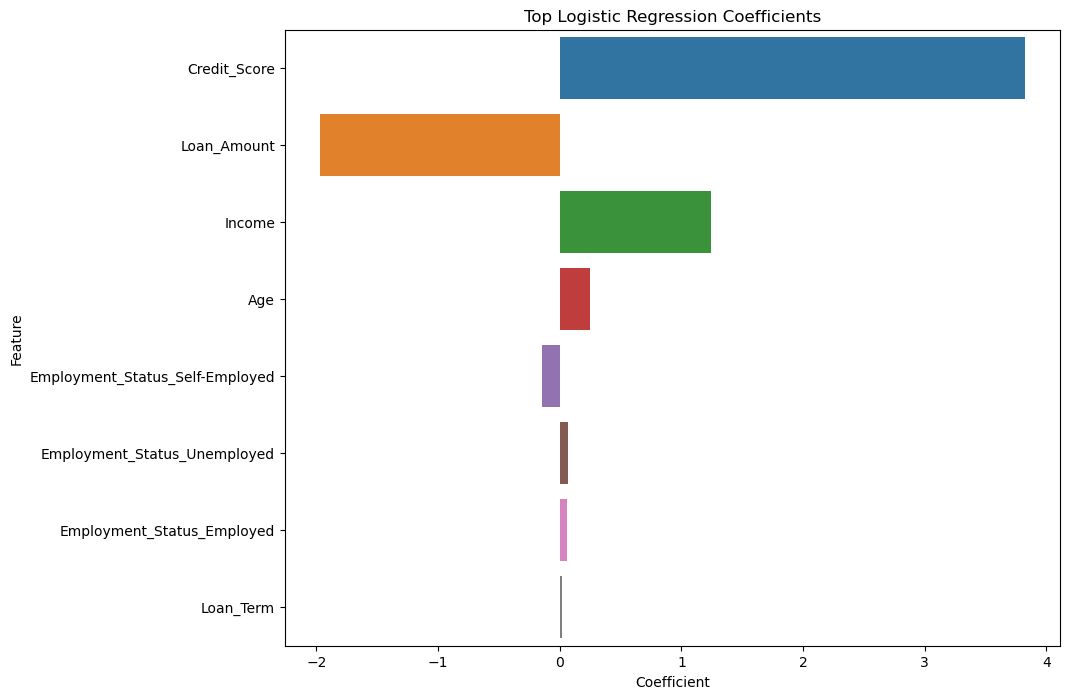

In [60]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Absolute"] = (importance["Coefficient"].abs())

importance = importance.sort_values(by = "Absolute", ascending = False)

plt.figure(figsize = (10,8))

sns.barplot(data = importance.head(15),
    x = "Coefficient",
    y = "Feature"
)
plt.title("Top Logistic Regression Coefficients")
plt.show()

In [84]:
ans = model.predict(np.array([X.iloc[1996]]))

print(ans)

if ans > 0.5:
    print("Approved")
else:
    print("Reject")

[1]
Approved


In [74]:
df.tail()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed
1995,63,87580,761,29716,48,1,1.0,0.0,0.0
1996,67,27368,695,13601,36,0,1.0,0.0,0.0
1997,69,105436,636,37018,36,0,0.0,1.0,0.0
1998,24,116136,441,9061,48,0,1.0,0.0,0.0
1999,20,66403,616,9609,12,0,0.0,0.0,1.0
